# PBMRS on FX: does the fragility statistic add information beyond volatility?
**GMSG application work sample - FX coverage | Salman**

This notebook was reviewed against GMSG's available FX deck, *FX - Asia Becomes Dollar
Pressure Point* (31 July 2026). The deck's "market caught offside" language is being
operationalized as a crowded-positioning/fragility claim; it is not a unique translation
into PBMRS parameters.

The original registered event study remains unchanged and is reported exactly as registered.
It did not execute because only two of five held-out episodes found matched controls. A new,
separately registered continuous test therefore asks whether rolling minimum-distance J
predicts forward stress after controlling for current realized volatility. The estimand
changed because the old design had no testable sample, not because its results were unfavourable.

In [1]:
import hashlib, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from pbmrs_core import __version__, SimConfig, load_config
from pbmrs_core.calibration import load_npz_cache, wilson_interval
from pbmrs_core.fx import fetch_fx, discover_definitions, fetch_fx_positioning, validate_raw_tree
from pbmrs_core.fx_analysis import load_study
from pbmrs_core.fx_continuous import load_continuous_study

candidates = [Path.cwd(), Path.cwd().parent, Path.cwd() / "Public Repo"]
ROOT = next(p for p in candidates if (p / "configs/fx_study.json").exists())
CACHE = ROOT / "notebooks/fx_cache"
CONTINUOUS_RAW = ROOT / "notebooks/fx_continuous_cache/raw"
DECK = ROOT / "reference/FX.pdf"
frozen, sim, manifest, result = load_study(ROOT)
continuous_frozen, continuous_manifest, continuous = load_continuous_study(ROOT)
design, continuous_design = frozen["design"], continuous_frozen["design"]
cfg = SimConfig(**load_config(ROOT / "configs/base.yaml")["simulation"])
assert __version__ == "0.2.2" and cfg.alpha_r == 12.0
assert frozen["registered_at_utc"] < sim["started_at_utc"] < manifest["computed_at_utc"]
assert continuous_frozen["registered_at_utc"] < continuous_manifest["started_at_utc"] < continuous_manifest["computed_at_utc"]
assert continuous["registered_event_design_sha256"] == frozen["design_sha256"]
series = {pair: fetch_fx(pair, cache_dir=CACHE / "raw", start=design["start"], end=design["end"])
          for pair in ("JPY", "EUR")}
primary = next(row for row in result["specifications"] if row["primary"])
primary_continuous = next(row for row in continuous["regressions"]
                          if row["series"] == "JPY" and row["outcome"] == continuous_design["primary"]["outcome"])
plt.rcParams.update({"figure.figsize": (11, 4), "axes.spines.top": False,
                    "axes.spines.right": False, "axes.grid": True, "grid.alpha": .18,
                    "font.size": 10, "axes.titlesize": 12})
colors = {"JPY": "#147d92", "EUR": "#c56a2d", "Gaussian": "#777777"}
display(pd.DataFrame([
    {"design": "registered event study", "registered_at_utc": frozen["registered_at_utc"],
     "sha256": frozen["design_sha256"], "verified": True},
    {"design": "registered continuous test", "registered_at_utc": continuous_frozen["registered_at_utc"],
     "sha256": continuous_frozen["design_sha256"], "verified": True},
]))
print("Deck reference:", DECK, "| present:", DECK.exists())
display(Markdown(f"**Registered event study:** {primary['status']} - {primary['n_labelled']} labelled, "
                 f"{primary['n_matched']} matched. The test did not execute; this is not a tested null.**"))

,design,registered_at_utc,sha256,verified
0,registered event study,2026-09-15T15:38:58.123878+00:00,d5bd9607cbae2c0f1bfa7b027c9d0efb8d6fcb900db8be...,True
1,registered continuous test,2026-09-15T17:25:05.665252+00:00,70f651031e9d5891791977568a56cb630c7c4a4dd615b2...,True


Deck reference: C:\Users\Mghou\PBMRS-1\Public Repo\reference\FX.pdf | present: False


**Registered event study:** insufficient_events - 5 labelled, 2 matched. The test did not execute; this is not a tested null.**

## Designs and interpretation

The event design uses a held-out 2018 split and remains the primary result under its original
question. Its configuration, hash, timestamp, twelve specifications, exclusions, and result
bytes are unchanged. The continuous design is a new question frozen before its coefficients
were computed: 500-session rolling estimates, 21-session steps, the full 2003-2026 sample,
and the next 21 sessions as a non-overlapping outcome window.

The continuous primary estimand is `b` in
`forward realized volatility = a + b*J_hat + c*log(current realized volatility) + error`.
Maximum drawdown and absolute terminal return are secondary. Circular moving-block pairs
bootstrap intervals use 4,999 resamples and 24-step blocks. Roughly twelve independent
500-session spans make wide intervals expected, despite 259 reported estimates per series.

## Exhibit 1 - Why move from crude to FX?

These prior scale measurements came from the supplied build brief; they are motivation rather
than newly replicated results. Stability at FX scale makes inference feasible but does not
establish that J measures carry fragility.

,analogue,sigma_eps,pathological_J040,pathological_J078,flow_share_J040,flow_share_J078
0,EURUSD,0.0045,0.000,0.000,0.24,0.41
1,SPX,0.0110,0.000,0.048,0.20,NaN
2,WTI,0.0418,0.992,1.000,NaN,NaN


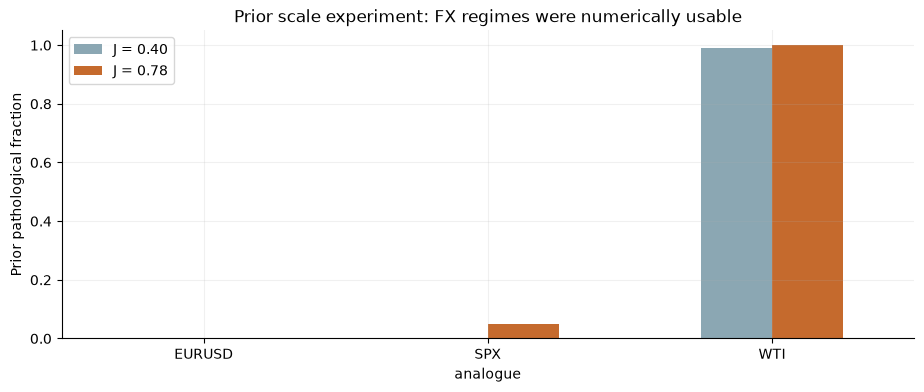

In [2]:
prior = pd.DataFrame(design["historical_scale_evidence"]["rows"])
display(prior)
ax = prior.set_index("analogue")[["pathological_J040", "pathological_J078"]].plot.bar(
    color=["#8ba7b3", "#c56a2d"], rot=0)
ax.set(ylabel="Prior pathological fraction", title="Prior scale experiment: FX regimes were numerically usable")
ax.legend(["J = 0.40", "J = 0.78"]); plt.show()

## Exhibit 2 - New stability screen at solved FX scales

Each point uses 500 paths and 2,000 post-burn returns. Eligibility requires an observed
pathological fraction no greater than 1%; Wilson intervals retain uncertainty. `J*beta=1`
is an agent-layer reference, not a proven boundary for the coupled system.

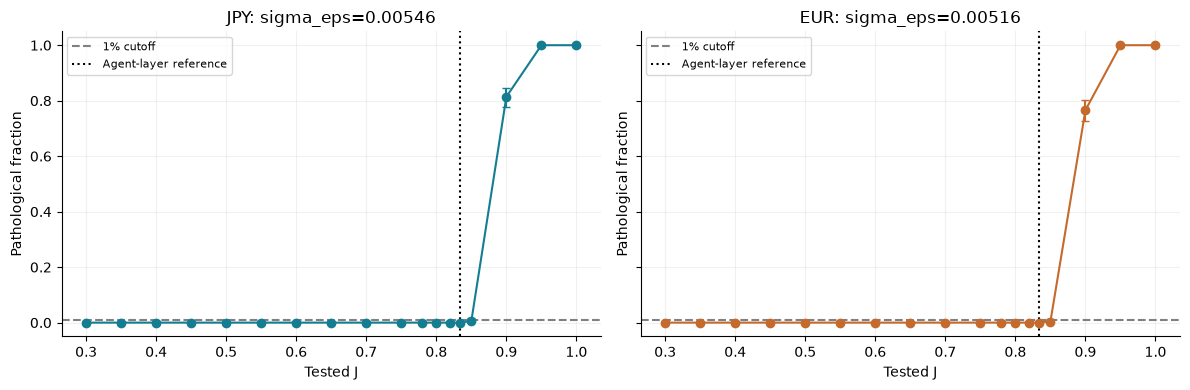

,pair,eligible_tested_J
0,JPY,"[0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0..."
1,EUR,"[0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0..."


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, pair in zip(axes, ("JPY", "EUR")):
    table = pd.DataFrame(sim["stability"][pair])
    ax.errorbar(table.J, table.fraction,
                yerr=np.maximum(0, [table.fraction-table.lo, table.hi-table.fraction]),
                fmt="o-", color=colors[pair], capsize=3)
    ax.axhline(.01, color="grey", ls="--", label="1% cutoff")
    ax.axvline(1/cfg.beta, color="black", ls=":", label="Agent-layer reference")
    ax.set(title=f"{pair}: sigma_eps={sim['scale'][pair]['sigma_eps']:.5f}",
           xlabel="Tested J", ylabel="Pathological fraction")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
display(pd.DataFrame({"pair": ["JPY", "EUR"],
                      "eligible_tested_J": [sim["eligible"]["JPY"], sim["eligible"]["EUR"]]}))

## Exhibit 3 - Market context and the deck's independently detected intervention window

Both return series are USD per foreign-currency unit. JPY is inverted from
[FRED DEXJPUS](https://fred.stlouisfed.org/series/DEXJPUS); EUR uses
[DEXUSEU](https://fred.stlouisfed.org/series/DEXUSEU). CFTC TFF leveraged-money positioning
supplies retrospective labels but never enters J inference.

[The GMSG deck's intervention discussion](../reference/FX.pdf#page=23) describes the
30-31 July joint US-Japan intervention, USDJPY moving from about 163 to 158 in under an hour,
and volatility consistent with "a market caught offside." Without using that narrative, the
detector identified the corresponding 28 July-4 August interval: prior net short exposure
was 0.2359 of open interest, fell 0.0909, and appreciation was 3.44 prior-volatility standard
units. PBMRS has no policy-shock mechanism, so this corroborates the fragile setup?not the
intervention trigger. The registered matcher then excluded it for insufficient controls.

,interval_start,date,net_short_before,net_short_fall,appreciation_z,reason
0,2026-07-28,2026-08-04,0.235888,0.090857,3.441145,insufficient prehistory or matched controls


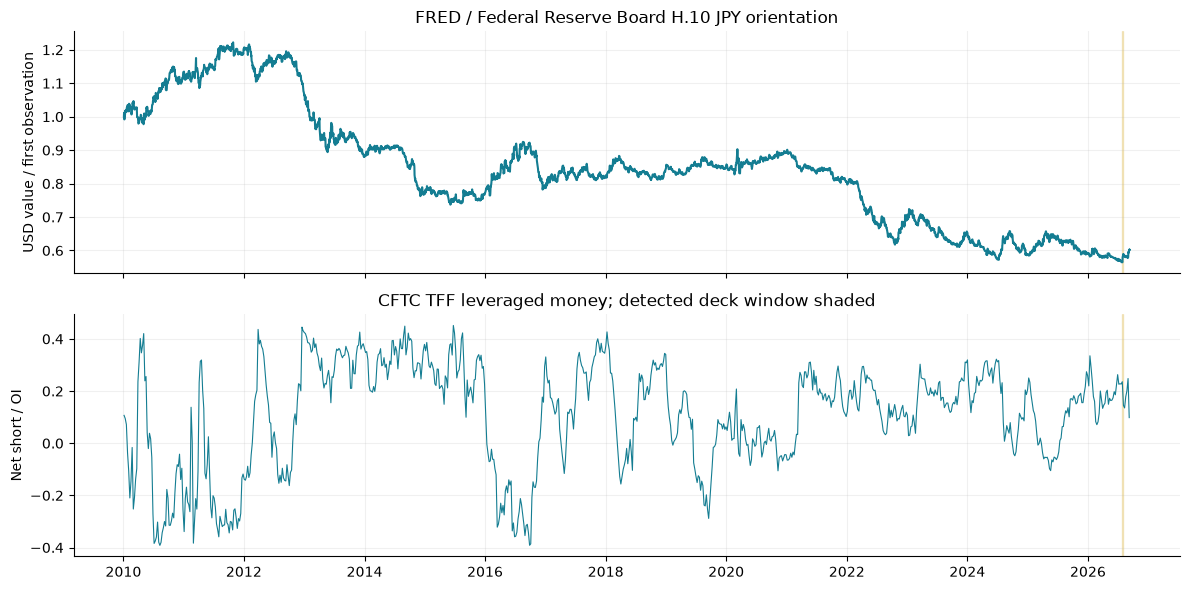

In [4]:
deck_event = next(event for event in primary["excluded"] if event["date"] == "2026-08-04")
assert deck_event["interval_start"] == "2026-07-28"
assert np.isclose(deck_event["net_short_before"], .2359, atol=5e-5)
assert np.isclose(deck_event["net_short_fall"], .0909, atol=5e-5)
assert np.isclose(deck_event["appreciation_z"], 3.44, atol=.005)
display(pd.DataFrame([{k: deck_event[k] for k in
                      ["interval_start", "date", "net_short_before", "net_short_fall",
                       "appreciation_z", "reason"]}]))
definitions = discover_definitions(CACHE / "raw")
definition = next(d for d in definitions if d.key == design["positioning_primary"])
cot, _ = fetch_fx_positioning(definition, "JPY", cache_dir=CACHE / "raw",
                              start=design["start"], end=design["end"])
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(series["JPY"].dates, series["JPY"].close/series["JPY"].close[0], color=colors["JPY"])
axes[1].plot(cot.dates, -cot.net_over_oi, color=colors["JPY"], lw=.8)
for ax in axes: ax.axvspan(pd.Timestamp("2026-07-28"), pd.Timestamp("2026-08-04"), color="#d7a928", alpha=.25)
axes[0].set(ylabel="USD value / first observation", title="FRED / Federal Reserve Board H.10 JPY orientation")
axes[1].set(ylabel="Net short / OI", title="CFTC TFF leveraged money; detected deck window shaded")
plt.tight_layout(); plt.show()

The policy action is external to the simulator, just as a physical supply shock is external
in the WTI application. The useful model question is narrower: did the pre-existing return
dynamics carry stress information beyond observable volatility?

## Exhibit 4 - Empirical fingerprint and tail gap

The inference statistic is the ACF of demeaned squared returns at lags 1-8. Pointwise 95%
stationary-bootstrap intervals use 1,000 draws and mean block length 21. SD and excess
kurtosis are separate diagnostics; ACF adequacy does not test the tails.

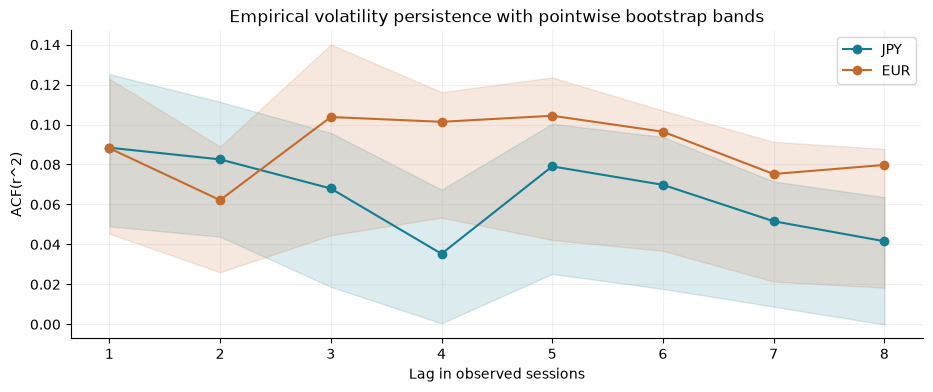

,pair,n_returns,daily_SD,excess_kurtosis,kurtosis_lo,kurtosis_hi
0,JPY,4175,0.005894,4.209342,3.097425,5.442965
1,EUR,4175,0.005183,1.830085,1.321367,2.430915


,pair,J,mean,path_p025,path_p975,empirical,gap
0,JPY,0.40,0.001810,-0.186710,0.244793,4.209342,4.207532
1,JPY,0.78,-0.011910,-0.219679,0.215621,4.209342,4.221251
2,EUR,0.40,0.001974,-0.188932,0.247340,1.830085,1.828111
3,EUR,0.78,-0.012162,-0.221419,0.220887,1.830085,1.842248


In [5]:
fig, ax = plt.subplots()
rows = []
for pair in ("JPY", "EUR"):
    f = result["pairs"][pair]["fingerprint"]; x = np.arange(1, 9)
    ax.plot(x, f["point"][:8], "o-", label=pair, color=colors[pair])
    ax.fill_between(x, f["lo"][:8], f["hi"][:8], alpha=.15, color=colors[pair])
    rows.append({"pair": pair, "n_returns": result["pairs"][pair]["n_returns"],
                 "daily_SD": f["point"][8], "excess_kurtosis": f["point"][9],
                 "kurtosis_lo": f["lo"][9], "kurtosis_hi": f["hi"][9]})
ax.set(xlabel="Lag in observed sessions", ylabel="ACF(r^2)", title="Empirical volatility persistence with pointwise bootstrap bands")
ax.legend(); plt.show(); display(pd.DataFrame(rows))
display(pd.DataFrame([{"pair": pair, **row} for pair in ("JPY", "EUR")
                      for row in result["pairs"][pair]["kurtosis"]]))

## Exhibit 5 - Rolling JPY estimates and why T=250 is nearly uninformative

J_hat minimizes standardized D-sum; it is never selected by the largest p-value. Shaded points
are exact non-rejected grid values, not a continuous-J interval. Empty and disconnected sets
remain visible. Monthly steps make predictor windows overlap.

The matched Gaussian control is non-rejected somewhere in **80.2% of T=250 windows** versus
**48.4% of T=500 windows**. At T=250, independent noise passes roughly four times in five, so
those broad inversion sets carry little discriminatory information. T=250 remains visible only
because it was declared; the continuous test uses T=500.

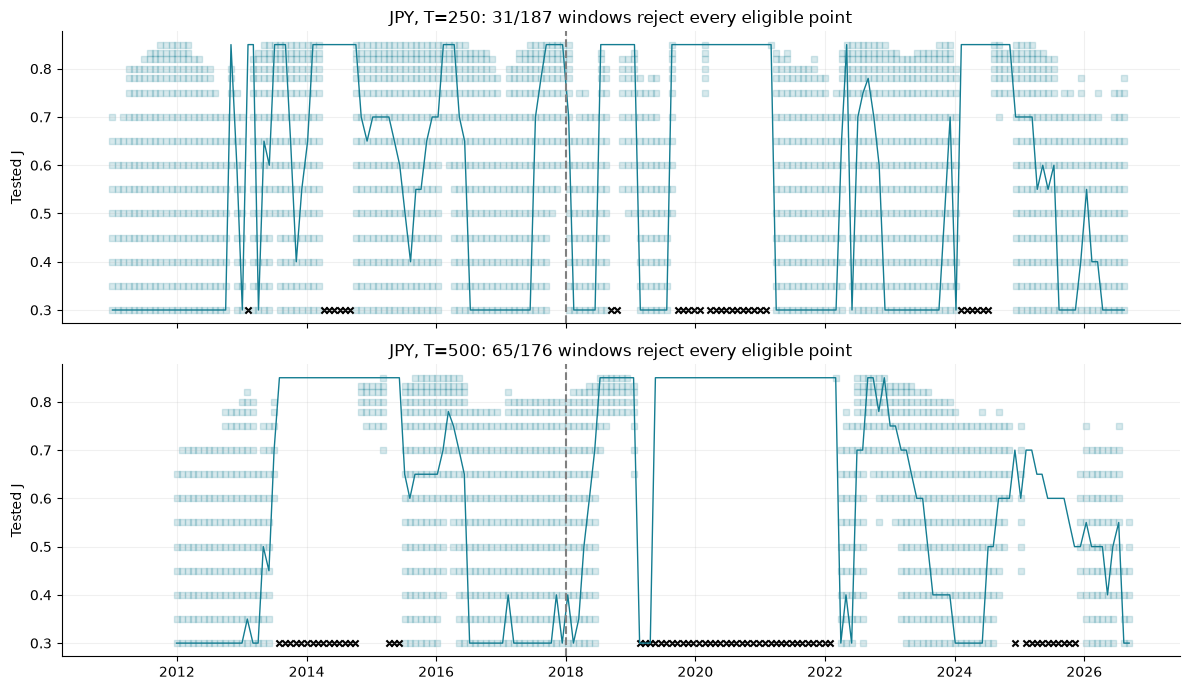

,pair,window,n,any_non_rejection_rate
0,JPY,250,500,0.802
1,JPY,500,500,0.484
2,EUR,250,500,0.804
3,EUR,500,500,0.500


In [6]:
def draw_rolling(ax, pair, T):
    rows = result["pairs"][pair]["rolling"][str(T)]
    dates = pd.to_datetime([row["date"] for row in rows])
    for day, row in zip(dates, rows):
        ax.scatter([day]*len(row["confidence_set"]), row["confidence_set"], marker="s",
                   s=13, alpha=.17, color=colors[pair])
    ax.plot(dates, [row["J_hat"] for row in rows], color=colors[pair], lw=1)
    empty = np.array([row["empty_set"] for row in rows])
    ax.scatter(dates[empty], [sim["eligible"][pair][0]]*empty.sum(), marker="x", color="black", s=20)
    ax.axvline(pd.Timestamp(design["split"]), color="grey", ls="--")
    ax.set(ylabel="Tested J", title=f"{pair}, T={T}: {empty.sum()}/{len(rows)} windows reject every eligible point")
gaussian_rates = pd.DataFrame(result["gaussian"])
check = gaussian_rates[gaussian_rates.pair == "JPY"].set_index("window").any_non_rejection_rate
assert np.isclose(check.loc[250], .802) and np.isclose(check.loc[500], .484)
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for ax, T in zip(axes, design["windows"]): draw_rolling(ax, "JPY", T)
plt.tight_layout(); plt.show()
display(gaussian_rates[["pair", "window", "n", "any_non_rejection_rate"]])

## Exhibit 6 - New continuous test: no resolved JPY information beyond volatility

Every 500-session window contributes an observation, stepped by 21 sessions. The next 21
returns never overlap across adjacent rows. The regression controls for `log(current realized
volatility)` because J is estimated from squared-return dependence; without that control,
any association would merely restate volatility clustering.

The primary JPY coefficient is reported without re-specification. EUR is run identically as a
falsification, and one JPY-SD-matched independent Gaussian series traverses the same rolling
estimator, outcomes, regression, and bootstrap. Intervals are block-bootstrap percentile
intervals, not naive iid intervals.

,series,n,b_J_hat,b_lo,b_hi,b_per_0.1J_daily_vol_bp,lo_per_0.1J_bp,hi_per_0.1J_bp,block_length_steps,rank_deficient_resamples_redrawn,resolved_beyond_zero
0,JPY,259,0.000806,-0.001393,0.003311,0.805810,-1.393494,3.310833,24,0,False
1,EUR,259,0.001841,-0.000160,0.004045,1.840512,-0.159995,4.044911,24,0,False
2,Gaussian,259,-0.000949,-0.004286,0.013840,-0.948542,-4.285736,13.840424,24,93,False


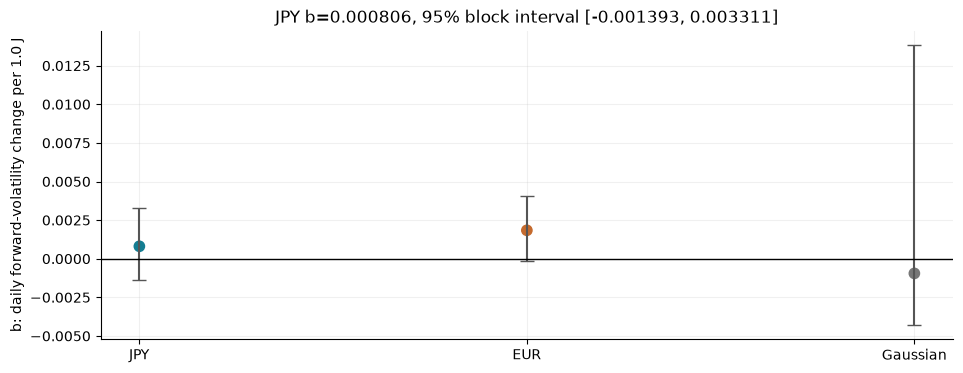

**Finding:** at this scale, the JPY statistic adds no statistically resolved information beyond volatility clustering. EUR and Gaussian intervals also include zero. 

In [7]:
outcome = continuous_design["primary"]["outcome"]
slopes = pd.DataFrame([row for row in continuous["regressions"] if row["outcome"] == outcome])
slopes["b_per_0.1J_daily_vol_bp"] = slopes.b_J_hat * 1000
slopes["lo_per_0.1J_bp"] = slopes.b_lo * 1000
slopes["hi_per_0.1J_bp"] = slopes.b_hi * 1000
slopes["resolved_beyond_zero"] = ~((slopes.b_lo <= 0) & (slopes.b_hi >= 0))
display(slopes[["series", "n", "b_J_hat", "b_lo", "b_hi", "b_per_0.1J_daily_vol_bp",
                "lo_per_0.1J_bp", "hi_per_0.1J_bp", "block_length_steps",
                "rank_deficient_resamples_redrawn", "resolved_beyond_zero"]])
x = np.arange(len(slopes)); fig, ax = plt.subplots()
ax.errorbar(x, slopes.b_J_hat, yerr=[slopes.b_J_hat-slopes.b_lo, slopes.b_hi-slopes.b_J_hat],
            fmt="none", ecolor="#555555", capsize=5)
ax.scatter(x, slopes.b_J_hat, c=[colors[s] for s in slopes.series], s=55)
ax.axhline(0, color="black", lw=1); ax.set_xticks(x, slopes.series)
ax.set(ylabel="b: daily forward-volatility change per 1.0 J",
       title=f"JPY b={primary_continuous['b_J_hat']:.6f}, 95% block interval [{primary_continuous['b_lo']:.6f}, {primary_continuous['b_hi']:.6f}]")
plt.show()
display(Markdown("**Finding:** at this scale, the JPY statistic adds no statistically resolved "
                 "information beyond volatility clustering. EUR and Gaussian intervals also include zero. "))

## Exhibit 7 - Secondary stress outcomes and volatility-stratified presentation

Maximum drawdown and absolute terminal return were frozen as secondary outcomes. They cannot
replace the primary forward-volatility result. The descriptive table sorts J_hat into quintiles
within current-volatility terciles; it is a legibility aid, not a second inferential test.

,series,outcome,n,b_J_hat,b_lo,b_hi,c_log_current_volatility,block_length_steps
0,JPY,forward_max_drawdown,259,-0.000529,-0.014442,0.010403,0.009104,24
1,JPY,forward_absolute_terminal_return,259,-0.003650,-0.014749,0.010932,0.008029,24
2,EUR,forward_max_drawdown,259,0.008794,-0.002725,0.022504,0.014948,24
3,EUR,forward_absolute_terminal_return,259,0.007459,-0.002930,0.018095,0.014429,24
4,Gaussian,forward_max_drawdown,259,-0.000371,-0.087769,0.089608,0.006862,24
5,Gaussian,forward_absolute_terminal_return,259,-0.001680,-0.041695,0.011892,-0.019307,24


J_hat_quintile,1,2,3,4,5
volatility_tercile,,,,,
1,0.005689,0.005655,0.006629,0.008552,0.004310
2,0.005493,0.005252,0.006166,0.006248,0.004965
3,0.005786,0.005370,0.006085,0.008047,NaN


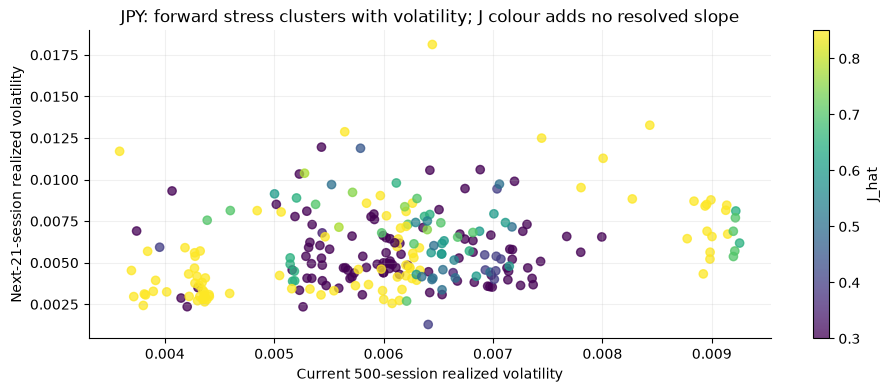

In [8]:
secondary = pd.DataFrame([row for row in continuous["regressions"]
                          if row["outcome"] != continuous_design["primary"]["outcome"]])
display(secondary[["series", "outcome", "n", "b_J_hat", "b_lo", "b_hi",
                   "c_log_current_volatility", "block_length_steps"]])
quintiles = pd.DataFrame(continuous["quintiles"]["JPY"])
display(quintiles.pivot(index="volatility_tercile", columns="J_hat_quintile",
                        values="mean_forward_stress"))
panel = pd.DataFrame(continuous["series"]["JPY"]["panel"])
fig, ax = plt.subplots()
points = ax.scatter(panel.current_realized_volatility, panel.forward_realized_volatility,
                    c=panel.J_hat, cmap="viridis", alpha=.75)
fig.colorbar(points, ax=ax, label="J_hat")
ax.set(xlabel="Current 500-session realized volatility", ylabel="Next-21-session realized volatility",
       title="JPY: forward stress clusters with volatility; J colour adds no resolved slope")
plt.show()

## Exhibit 8 - Registered event study, demoted to a descriptive result

The registered JPY test remains `insufficient_events`: five held-out labels, two matches, and
therefore no effect interval or permutation p-value. It did not execute; there is no null result.

A clearly post-hoc arm widens the calendar pool to +/-1 year, uses prior 250-session volatility,
and selects up to five nearest controls inside a 0.50 log-volatility caliper. It matches all five
labels, including the deck event. Because these rules were chosen after observing sample failure,
its interval and p-value are exploratory and have no pre-registered interpretation.

,pair,window,segment,n_labelled,n_matched,effect,lo,hi,p_value,status
0,JPY,500,validation,5,2,None,None,None,None,insufficient_events


,date,score,difference,pre_event_empty_set_fraction
0,2021-11-30,0.850000,1.110223e-16,1.0
1,2024-08-06,0.461905,1.428571e-01,0.0


,status,n_labelled,n_matched,effect_descriptive,lo,hi,p_value,n_permutation,n_bootstrap
0,post_hoc_exploratory,5,5,0.002095,-0.058231,0.107143,0.4478,4999,4999


,interval_start,date,n_controls,max_selected_log_vol_distance,difference
0,2020-03-03,2020-03-10,5,0.027414,5.238095e-03
1,2021-11-23,2021-11-30,5,0.072785,1.110223e-16
2,2024-07-30,2024-08-06,5,0.106929,1.428571e-01
3,2026-01-20,2026-01-27,5,0.066830,-9.523810e-02
4,2026-07-28,2026-08-04,5,0.275044,-4.238095e-02


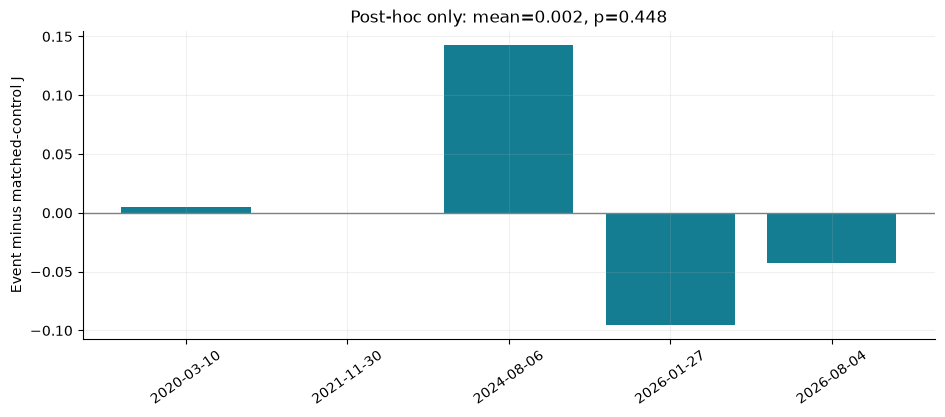

In [9]:
fields = ["pair", "window", "segment", "n_labelled", "n_matched", "effect", "lo", "hi", "p_value", "status"]
display(pd.DataFrame([{key: primary.get(key) for key in fields}]))
if primary["matched"]:
    display(pd.DataFrame(primary["matched"])[["date", "score", "difference", "pre_event_empty_set_fraction"]])
exploratory = continuous["post_hoc_exploratory_event"]
display(pd.DataFrame([{k: exploratory.get(k) for k in
                      ["status", "n_labelled", "n_matched", "effect_descriptive", "lo", "hi", "p_value",
                       "n_permutation", "n_bootstrap"]}]))
explore_rows = pd.DataFrame(exploratory["matched"])
display(explore_rows[["interval_start", "date", "n_controls", "max_selected_log_vol_distance", "difference"]])
deck_match = explore_rows.loc[explore_rows.date == "2026-08-04"].iloc[0]
assert deck_match.n_controls == 5
fig, ax = plt.subplots()
ax.bar(explore_rows.date, explore_rows.difference, color=colors["JPY"])
ax.axhline(0, color="grey", lw=1); ax.tick_params(axis="x", rotation=35)
ax.set(ylabel="Event minus matched-control J",
       title=f"Post-hoc only: mean={exploratory['effect_descriptive']:.3f}, p={exploratory['p_value']:.3f}")
plt.show()

## Exhibit 9 - Fixed-split registered evaluation remains visible

The event study's nuisance calibration and grid were frozen before 2018. Later rolling estimates
use information available by each endpoint, but current-vintage data and retrospective matching
make this neither a live signal nor an archived-vintage backtest.

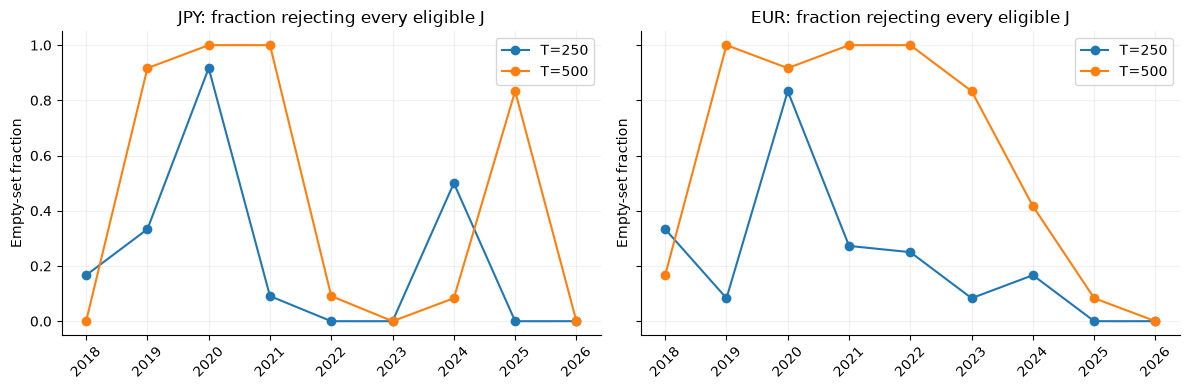

,pair,window,segment,n_labelled,n_matched,effect,lo,hi,p_value,status
0,JPY,500,training,2,2,None,None,None,None,insufficient_events
1,JPY,500,validation,5,2,None,None,None,None,insufficient_events


In [10]:
walk = pd.DataFrame(result["walk_forward"])
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, pair in zip(axes, ("JPY", "EUR")):
    for T in design["windows"]:
        sub = walk[(walk.pair == pair) & (walk.window == T)]
        ax.plot(sub.year, sub.empty_set_fraction, "o-", label=f"T={T}")
    ax.tick_params(axis="x", rotation=45)
    ax.set(title=pair + ": fraction rejecting every eligible J", ylabel="Empty-set fraction")
    ax.legend()
plt.tight_layout(); plt.show()
display(pd.DataFrame([{k: row.get(k) for k in fields} for row in result["specifications"]
                      if row["pair"] == "JPY" and row["window"] == 500]))

## Exhibit 10 - FX-scale calibration and fixed-J power

Eight true-model controls assess nominal 10% size; all Wilson intervals cover nominal. Power
concerns a fixed-J contrast, not either association test. Common random numbers induce correlated
Monte Carlo errors and are not independent replications.

,pair,window,J,n,rejections,rate,lo,hi,covers_nominal
0,JPY,250,0.40,500,40,0.080,0.059298,0.107106,True
1,JPY,250,0.78,500,48,0.096,0.073174,0.124987,True
2,JPY,500,0.40,500,54,0.108,0.083723,0.138255,True
3,JPY,500,0.78,500,45,0.090,0.067943,0.118309,True
4,EUR,250,0.40,500,39,0.078,0.057581,0.104854,True
5,EUR,250,0.78,500,52,0.104,0.080194,0.133844,True
6,EUR,500,0.40,500,53,0.106,0.081957,0.136051,True
7,EUR,500,0.78,500,48,0.096,0.073174,0.124987,True


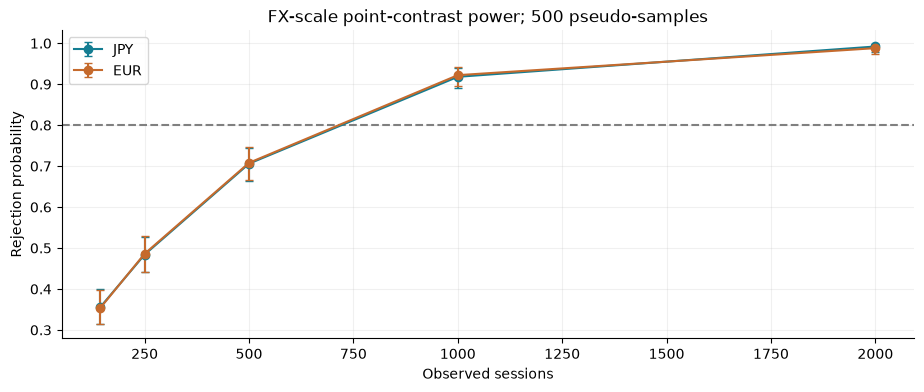

Controls whose 95% interval misses nominal size: **0/8**.

In [11]:
controls = pd.DataFrame(result["controls"]); power = pd.DataFrame(result["power"])
display(controls)
fig, ax = plt.subplots()
for pair in ("JPY", "EUR"):
    sub = power[power.pair == pair]
    ax.errorbar(sub["T"], sub.power, yerr=[sub.power-sub.lo, sub.hi-sub.power],
                fmt="o-", color=colors[pair], label=pair, capsize=3)
ax.axhline(.8, ls="--", color="grey")
ax.set(xlabel="Observed sessions", ylabel="Rejection probability",
       title="FX-scale point-contrast power; 500 pseudo-samples")
ax.legend(); plt.show()
display(Markdown(f"Controls whose 95% interval misses nominal size: **{int((~controls.covers_nominal).sum())}/{len(controls)}**."))

## Exhibit 11 - Twenty-one-session regime contrast with a volatility-scaled drawdown threshold

The old 5% recovery threshold was inherited from WTI and is too severe at FX scale. This main
presentation uses one pair-specific 21-session volatility unit:
`training daily SD * sqrt(21)`. It reclassifies the already cached horizon summaries and does
not change registered event results or rerun the simulator. Maximum drawdown, ending drawdown,
recovery, and terminal returns describe unconditional simulated regimes?not an FX forecast.

,pair,J,threshold_1sigma,n,mdd_mean,mdd_p95,ending_drawdown_mean,terminal_log_return_mean,qualifying,recovered,recovery_rate,recovery_lo,recovery_hi
0,JPY,0.40,0.028334,500,0.039674,0.086966,0.029237,-0.006073,303,24,0.079208,0.053803,0.115149
1,JPY,0.78,0.028334,500,0.056322,0.137879,0.047413,-0.021853,344,30,0.087209,0.061770,0.121766
2,EUR,0.40,0.027071,500,0.037724,0.081654,0.027801,-0.005812,300,22,0.073333,0.048924,0.108531
3,EUR,0.78,0.027071,500,0.053628,0.130450,0.045143,-0.020728,343,26,0.075802,0.052251,0.108749


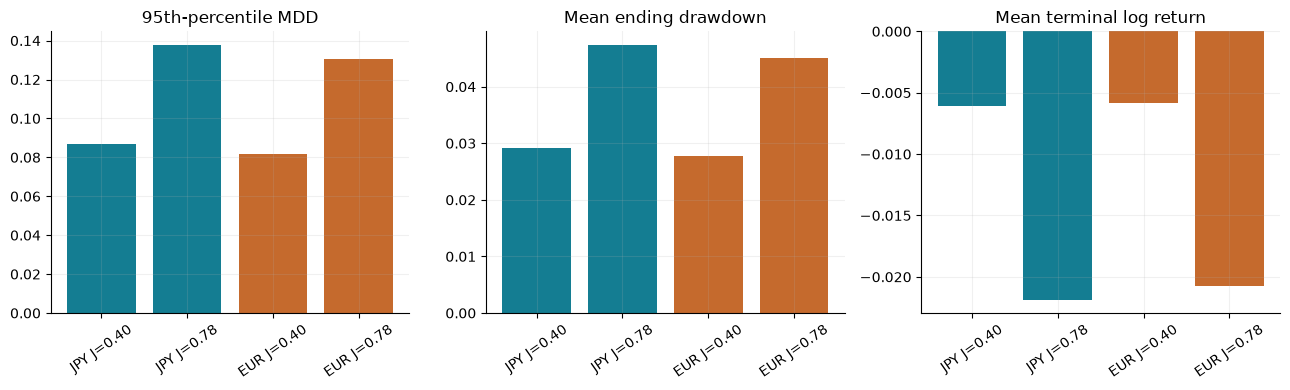

In [12]:
def cached(name):
    path = CACHE / name
    payload = load_npz_cache(path, sim["cache_keys"][name])
    assert payload is not None and hashlib.sha256(path.read_bytes()).hexdigest() == sim["cache_sha256"][name]
    return payload
horizon_rows = []
for pair in ("JPY", "EUR"):
    threshold = sim["scale"][pair]["target_sd"] * np.sqrt(21)
    for J in (0.4, sim["comparison_J"][pair]):
        h = cached(f"{pair}_horizon_J{J:.8f}.npz")["horizon"]
        qualifying = h[:, 0] >= threshold
        recovered = qualifying & np.isfinite(h[:, 3])
        lo, hi = wilson_interval(int(recovered.sum()), int(qualifying.sum()))
        horizon_rows.append({"pair": pair, "J": J, "threshold_1sigma": threshold,
                             "n": len(h), "mdd_mean": h[:,0].mean(), "mdd_p95": np.percentile(h[:,0],95),
                             "ending_drawdown_mean": h[:,2].mean(), "terminal_log_return_mean": h[:,1].mean(),
                             "qualifying": int(qualifying.sum()), "recovered": int(recovered.sum()),
                             "recovery_rate": recovered.sum()/qualifying.sum(), "recovery_lo": lo, "recovery_hi": hi})
horizons = pd.DataFrame(horizon_rows); display(horizons)
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
labels = [f"{row['pair']} J={row['J']:.2f}" for row in horizon_rows]
for ax, metric, title in zip(axes, ["mdd_p95", "ending_drawdown_mean", "terminal_log_return_mean"],
                              ["95th-percentile MDD", "Mean ending drawdown", "Mean terminal log return"]):
    ax.bar(labels, horizons[metric], color=[colors[row["pair"]] for row in horizon_rows])
    ax.tick_params(axis="x", rotation=35); ax.set_title(title)
plt.tight_layout(); plt.show()

## Conclusion and limits

The registered event test **did not execute**. Its hypothesis is neither supported nor refuted
under that design; the post-hoc widened match cannot replace it. The detector nevertheless found
the deck's intervention window independently, corroborating a crowded setup while saying nothing
about the policy trigger.

The separately registered continuous test does execute. For JPY, `b=0.000806` with a 95%
24-step block-bootstrap interval `[-0.001393, 0.003311]`. At this scale and with this statistic,
J adds no statistically resolved forward-volatility information beyond volatility clustering.
EUR and Gaussian intervals also cross zero; secondary stress outcomes do not overturn the primary.

Wide intervals are part of the finding: 259 stepped estimates arise from only about twelve
independent 500-session spans. Gaussian innovations omit intervention and jump mechanisms; the
empirical kurtosis gap remains. Fixed nuisance scale, finite J grid, current data vintage, daily
timing assumptions, and CFTC's incomplete view of OTC carry remain material limitations.

In [13]:
summary = pd.DataFrame([row for row in continuous["regressions"]
                        if row["outcome"] == continuous_design["primary"]["outcome"]])
summary["interval_contains_zero"] = (summary.b_lo <= 0) & (summary.b_hi >= 0)
display(summary[["series", "n", "b_J_hat", "b_lo", "b_hi", "c_log_current_volatility",
                 "interval_contains_zero"]])
assert summary.interval_contains_zero.all()

,series,n,b_J_hat,b_lo,b_hi,c_log_current_volatility,interval_contains_zero
0,JPY,259,0.000806,-0.001393,0.003311,0.003344,True
1,EUR,259,0.001841,-0.000160,0.004045,0.003694,True
2,Gaussian,259,-0.000949,-0.004286,0.013840,0.000384,True


## Appendix A - All registered event specifications and exclusions

Nothing below was altered by the continuous test. All twelve specifications, null fields,
matched episodes, and exclusions come directly from the original hashed `results.json`.

In [14]:
display(pd.DataFrame([{k: row.get(k) for k in ["primary", "label_pair", *fields]}
                      for row in result["specifications"]]))
excluded = [{"pair": row["pair"], "window": row["window"], "segment": row["segment"],
             "label_pair": row["label_pair"], **event}
            for row in result["specifications"] for event in row["excluded"]]
display(pd.DataFrame(excluded))

,primary,label_pair,pair,window,segment,n_labelled,n_matched,effect,lo,hi,p_value,status
0,False,JPY,JPY,250,training,2,2,None,None,None,None,insufficient_events
1,False,JPY,JPY,250,validation,5,2,None,None,None,None,insufficient_events
2,False,JPY,JPY,500,training,2,2,None,None,None,None,insufficient_events
3,True,JPY,JPY,500,validation,5,2,None,None,None,None,insufficient_events
4,False,JPY,EUR,250,training,2,1,None,None,None,None,insufficient_events
5,False,JPY,EUR,250,validation,5,2,None,None,None,None,insufficient_events
6,False,JPY,EUR,500,training,2,1,None,None,None,None,insufficient_events
7,False,JPY,EUR,500,validation,5,2,None,None,None,None,insufficient_events
8,False,EUR,EUR,250,training,2,1,None,None,None,None,insufficient_events
9,False,EUR,EUR,250,validation,1,0,None,None,None,None,insufficient_events


,pair,window,segment,label_pair,start_position,end_position,date,interval_start,net_short_before,net_short_fall,appreciation,appreciation_z,reason
0,JPY,250,validation,JPY,2543,2547,2020-03-10,2020-03-03,0.208015,0.169668,0.033844,4.084004,insufficient prehistory or matched controls
1,JPY,250,validation,JPY,4012,4016,2026-01-27,2026-01-20,0.289593,0.050951,0.031265,2.248167,insufficient prehistory or matched controls
2,JPY,250,validation,JPY,4143,4147,2026-08-04,2026-07-28,0.235888,0.090857,0.038686,3.441145,insufficient prehistory or matched controls
3,JPY,500,validation,JPY,2543,2547,2020-03-10,2020-03-03,0.208015,0.169668,0.033844,4.084004,insufficient prehistory or matched controls
4,JPY,500,validation,JPY,4012,4016,2026-01-27,2026-01-20,0.289593,0.050951,0.031265,2.248167,insufficient prehistory or matched controls
5,JPY,500,validation,JPY,4143,4147,2026-08-04,2026-07-28,0.235888,0.090857,0.038686,3.441145,insufficient prehistory or matched controls
6,EUR,250,training,JPY,1411,1415,2015-08-25,2015-08-18,0.423064,0.108933,0.036680,2.925031,insufficient prehistory or matched controls
7,EUR,250,validation,JPY,2543,2547,2020-03-10,2020-03-03,0.208015,0.169668,0.033844,4.084004,insufficient prehistory or matched controls
8,EUR,250,validation,JPY,4012,4016,2026-01-27,2026-01-20,0.289593,0.050951,0.031265,2.248167,insufficient prehistory or matched controls
9,EUR,250,validation,JPY,4143,4147,2026-08-04,2026-07-28,0.235888,0.090857,0.038686,3.441145,insufficient prehistory or matched controls


## Appendix B - Complete checks and legacy 5% horizon classification

Stability, scale-solve traces, power, walk-forward summaries, and the original 5% recovery
classification remain visible for full disclosure. The latter is not used in the main exhibit.

In [15]:
display(pd.concat([pd.DataFrame(sim["stability"][pair]).assign(pair=pair)
                   for pair in ("JPY", "EUR")], ignore_index=True))
display(pd.concat([pd.DataFrame(sim["scale"][pair]["trace"]).assign(pair=pair)
                   for pair in ("JPY", "EUR")], ignore_index=True))
display(pd.DataFrame(result["power"])); display(pd.DataFrame(result["horizons"]))

,J,count,n,fraction,lo,hi,pair
0,0.300000,0,500,0.000,4.336809e-19,0.007624,JPY
1,0.350000,0,500,0.000,4.336809e-19,0.007624,JPY
2,0.400000,0,500,0.000,4.336809e-19,0.007624,JPY
3,0.450000,0,500,0.000,4.336809e-19,0.007624,JPY
4,0.500000,0,500,0.000,4.336809e-19,0.007624,JPY
5,0.550000,0,500,0.000,4.336809e-19,0.007624,JPY
6,0.600000,0,500,0.000,4.336809e-19,0.007624,JPY
7,0.650000,0,500,0.000,4.336809e-19,0.007624,JPY
8,0.700000,0,500,0.000,4.336809e-19,0.007624,JPY
9,0.750000,0,500,0.000,4.336809e-19,0.007624,JPY


,sigma_eps,total_sd,pair
0,0.000010,0.001420,JPY
1,0.015000,0.016965,JPY
2,0.007505,0.008439,JPY
3,0.003757,0.004381,JPY
4,0.005631,0.006385,JPY
5,0.004694,0.005374,JPY
6,0.005163,0.005878,JPY
7,0.005397,0.006131,JPY
8,0.005514,0.006258,JPY
9,0.005456,0.006195,JPY


,pair,T,null_J,truth_J,n,rejections,power,lo,hi
0,JPY,144,0.4,0.78,500,178,0.356,0.315275,0.398921
1,JPY,250,0.4,0.78,500,242,0.484,0.440485,0.527759
2,JPY,500,0.4,0.78,500,353,0.706,0.664617,0.744242
3,JPY,1000,0.4,0.78,500,459,0.918,0.890645,0.938981
4,JPY,2000,0.4,0.78,500,496,0.992,0.979613,0.996885
5,EUR,144,0.4,0.78,500,177,0.354,0.313342,0.396884
6,EUR,250,0.4,0.78,500,243,0.486,0.442465,0.529748
7,EUR,500,0.4,0.78,500,354,0.708,0.666681,0.746148
8,EUR,1000,0.4,0.78,500,461,0.922,0.895146,0.942419
9,EUR,2000,0.4,0.78,500,494,0.988,0.974070,0.994489


,pair,J,horizon,n,mdd_mean,mdd_p95,terminal_mean,ending_drawdown_mean,qualifying_5pct,recovered_5pct,recovery_rate,recovery_lo,recovery_hi,median_recovery_sessions_if_observed
0,JPY,0.40,21,500,0.039674,0.086966,-0.006073,0.029237,148,2,0.013514,0.003714,0.047929,4.5
1,JPY,0.78,21,500,0.056322,0.137879,-0.021853,0.047413,234,5,0.021368,0.009161,0.049036,4.0
2,EUR,0.40,21,500,0.037724,0.081654,-0.005812,0.027801,129,2,0.015504,0.004262,0.054767,4.0
3,EUR,0.78,21,500,0.053628,0.130450,-0.020728,0.045143,230,5,0.021739,0.009321,0.049871,4.5


## Appendix C - Reproduction, hashes, seeds and provenance

The event registration/results and continuous registration/results have independent hashes and
ordered timestamps. The continuous raw cache is separate, so adding its 2003-2009 observations
cannot alter event-study input validation. Raw hashes use exact bytes; source hashes normalize
only line endings. Existing caches support offline execution.

Rebuild the continuous artifacts with `register_fx_continuous.py` once, then
`build_fx_continuous_results.py`, followed by `build_fx_notebook_reviewed.py`. Re-running the
registration script verifies the frozen design and refuses a mismatch.

In [16]:
display(pd.DataFrame([{"design": "event", "registered": frozen["registered_at_utc"],
                       "design_sha256": frozen["design_sha256"], "results_sha256": manifest["results_sha256"]},
                      {"design": "continuous", "registered": continuous_frozen["registered_at_utc"],
                       "design_sha256": continuous_frozen["design_sha256"],
                       "results_sha256": continuous_manifest["results_sha256"]}]))
display(pd.DataFrame([{"file": name, **entry} for name, entry in validate_raw_tree(CONTINUOUS_RAW).items()]))
display(pd.DataFrame([{"series": name, **{k:v for k,v in values.items() if k != "panel"}}
                      for name, values in continuous["series"].items()]))
display(pd.DataFrame([{"name": key, "value": value}
                      for key, value in continuous_design["bootstrap"].items()]))
print("Event result bytes unchanged:", hashlib.sha256((CACHE / "results.json").read_bytes()).hexdigest())
print("Continuous result:", continuous_manifest["results_sha256"])
print("All design, source, raw-data, simulation-dependency and result hashes validated at start.")

,design,registered,design_sha256,results_sha256
0,event,2026-09-15T15:38:58.123878+00:00,d5bd9607cbae2c0f1bfa7b027c9d0efb8d6fcb900db8be...,446f7376a7a7395c3770c468c10dd25164315814193d8a...
1,continuous,2026-09-15T17:25:05.665252+00:00,70f651031e9d5891791977568a56cb630c7c4a4dd615b2...,d34baf4732cf25c525a0774866d8979b37f90bd9476eab...


,file,byte_count,cache_file,request_parameters,retrieved_at_utc,sha256,source_name,url
0,fred_DEXJPUS_2003-01-01_2026-09-15.csv,108600,fred_DEXJPUS_2003-01-01_2026-09-15.csv,id=DEXJPUS&cosd=2003-01-01&coed=2026-09-15,2026-09-15T18:11:27.913688+00:00,ea20cdd83243752dd806fa53ed717f703e8c67bc6fd450...,fred_DEXJPUS_2003-01-01_2026-09-15.csv,https://fred.stlouisfed.org/graph/fredgraph.cs...
1,fred_DEXUSEU_2003-01-01_2026-09-15.csv,109849,fred_DEXUSEU_2003-01-01_2026-09-15.csv,id=DEXUSEU&cosd=2003-01-01&coed=2026-09-15,2026-09-15T18:11:29.880256+00:00,51851c8ea9cbcc9c262962ae3d3b96c76e2d19bde00460...,fred_DEXUSEU_2003-01-01_2026-09-15.csv,https://fred.stlouisfed.org/graph/fredgraph.cs...


,series,first_return_date,last_return_date,n_returns,n_estimates,daily_sd,matched_pair
0,JPY,2003-01-03,2026-09-11,5939,259,0.006199,NaN
1,EUR,2003-01-03,2026-09-11,5939,259,0.005625,NaN
2,Gaussian,2003-01-03,2026-09-11,5939,259,0.006062,JPY


,name,value
0,method,circular moving-block pairs bootstrap
1,block_length_steps,24
2,n_resamples,4999
3,seeds,"{'JPY': 782001, 'EUR': 782002, 'Gaussian': 782..."


Event result bytes unchanged: 446f7376a7a7395c3770c468c10dd25164315814193d8ae21bd9a6647744dc2d
Continuous result: d34baf4732cf25c525a0774866d8979b37f90bd9476eab5bdc8ea2c3393d0d72
All design, source, raw-data, simulation-dependency and result hashes validated at start.
